In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\mehwish data\semester 4\Final_projects\ExplainX_final_PAI\loan_data.csv")

In [3]:
print("\n FIRST 5 ROWS\n")
print(df.head())



 FIRST 5 ROWS

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2   

In [4]:
print("\n DATASET SHAPE\n")
print(df.shape)


 DATASET SHAPE

(614, 13)


In [5]:
print("\n COLUMN NAMES\n")
print(df.columns)


 COLUMN NAMES

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


In [6]:
print("\n DATA TYPES\n")
print(df.dtypes)



 DATA TYPES

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [7]:

print("\n DATASET INFO\n")
print(df.info())


 DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB
None


In [8]:
print("\n NULL VALUES\n")
print(df.isnull().sum())



 NULL VALUES

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [9]:
print("\n DUPLICATE ROWS\n")
print(df.duplicated().sum())


 DUPLICATE ROWS

0


In [10]:
print("\n NUMERICAL SUMMARY\n")
print(df.describe())


 NUMERICAL SUMMARY

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [11]:
print("\n LOAN STATUS COUNTS\n")
print(df['Loan_Status'].value_counts())


 LOAN STATUS COUNTS

Loan_Status
Y    422
N    192
Name: count, dtype: int64


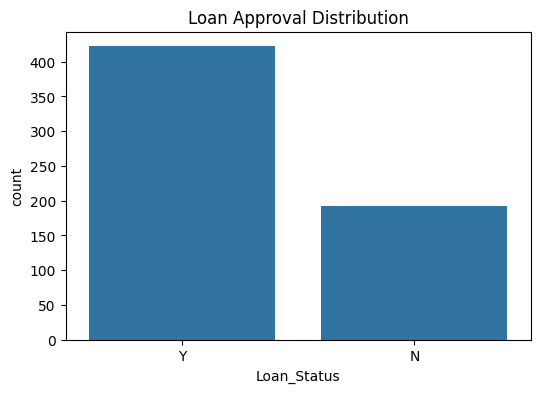

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

In [13]:
categorical_cols = df.select_dtypes(include='object').columns

print("\n CATEGORICAL COLUMNS\n")
print(categorical_cols)


 CATEGORICAL COLUMNS

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='str')


C:\Users\mehwi\AppData\Local\Temp\ipykernel_1776\3644007151.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [14]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("\n NUMERICAL COLUMNS\n")
print(numerical_cols)


 NUMERICAL COLUMNS

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


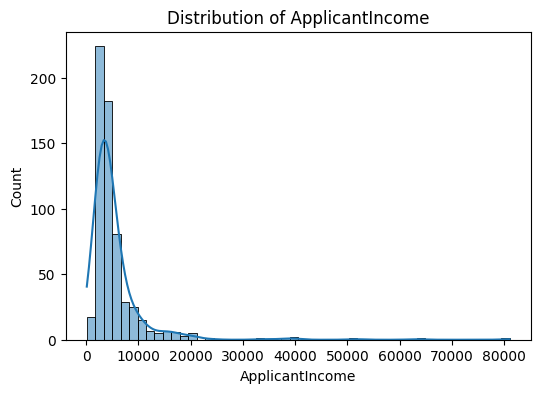

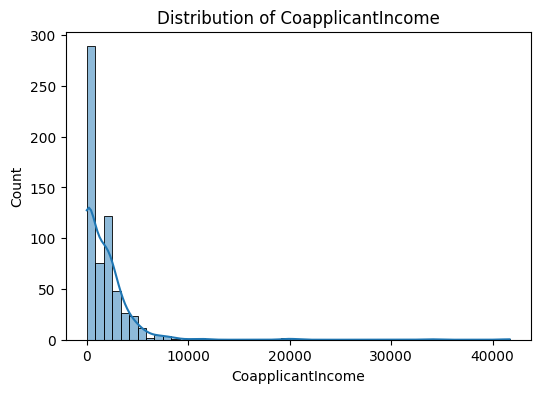

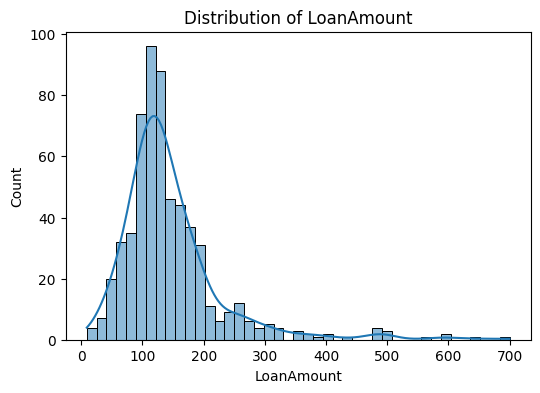

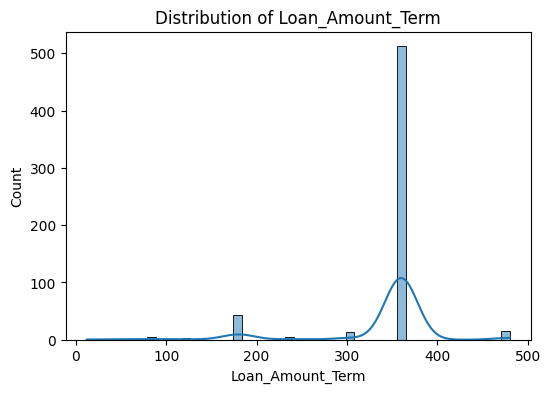

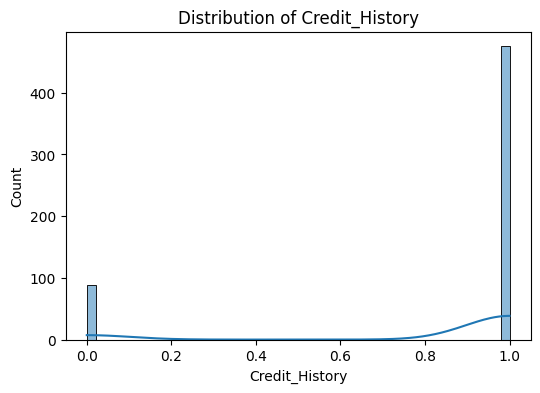

In [15]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

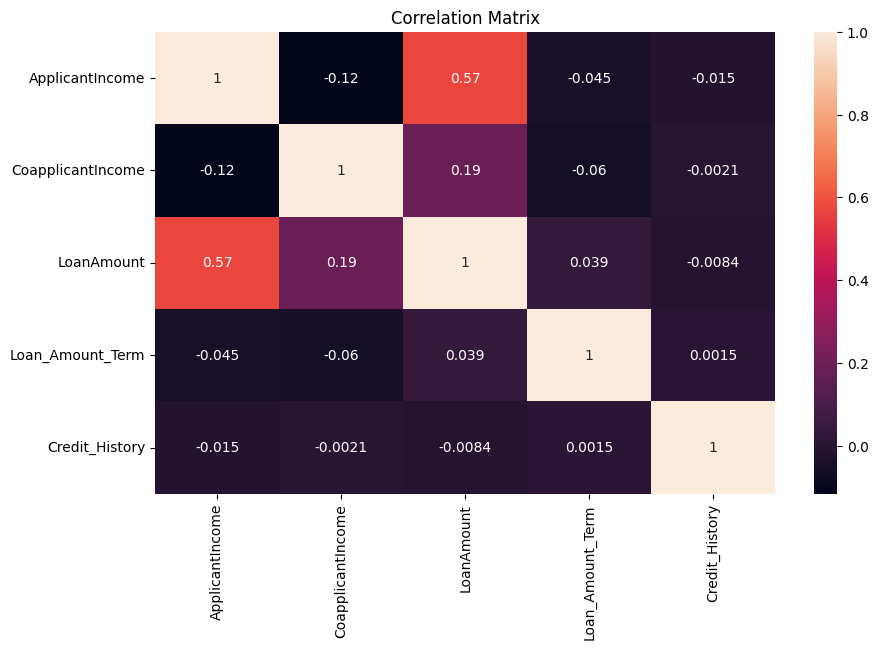

In [16]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

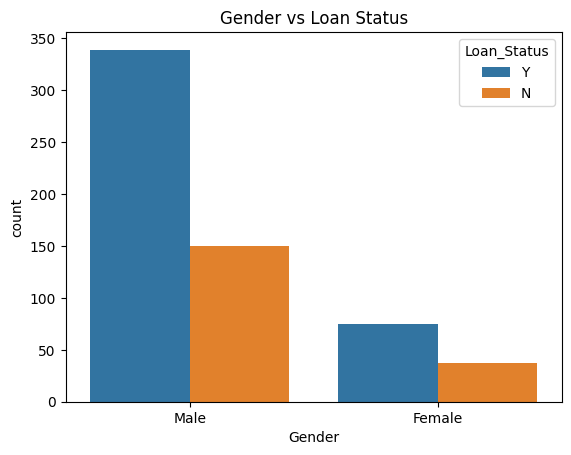

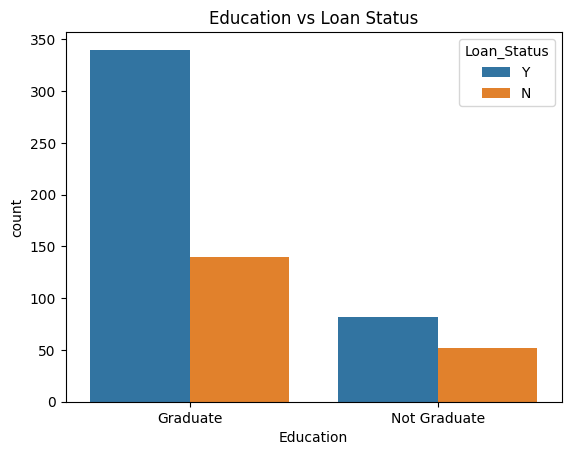

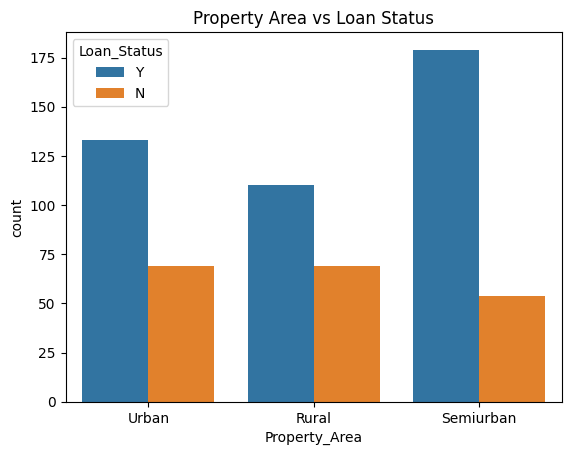

In [17]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Gender vs Loan Status")
plt.show()

# Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

# Property Area vs Loan Status
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()

In [18]:
print("""
=====================
EDA OBSERVATIONS
=====================

1. Dataset contains both categorical and numerical features.

2. Loan_Status is the target variable.

3. Some columns may contain missing values.

4. Loan_ID column is not useful for prediction.

5. Categorical columns need encoding.

6. Numerical columns may contain skewness.

7. Dataset is mostly clean and suitable for ML.

=====================
""")


EDA OBSERVATIONS

1. Dataset contains both categorical and numerical features.

2. Loan_Status is the target variable.

3. Some columns may contain missing values.

4. Loan_ID column is not useful for prediction.

5. Categorical columns need encoding.

6. Numerical columns may contain skewness.

7. Dataset is mostly clean and suitable for ML.




### PREPROCESSING

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
df.drop("Loan_ID", axis=1, inplace=True)

In [21]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [22]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

In [23]:
df['Dependents'] = df['Dependents'].replace('3+', '3')

In [24]:
encoder = LabelEncoder()

categorical_columns = [
    
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    
    df[col] = encoder.fit_transform(df[col])

In [25]:
print("\n NULL VALUES CHECK\n")

print(df.isnull().sum())


 NULL VALUES CHECK

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [26]:
print("\n FINAL DATASET INFO\n")

print(df.info())


 FINAL DATASET INFO

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB
None


In [27]:
print("\n PREPROCESSED DATASET\n")

print(df.head())


 PREPROCESSED DATASET

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            

In [28]:
df.to_csv("preprocessed_loan_data.csv", index=False)

print("\n Dataset Saved Successfully")


 Dataset Saved Successfully


### DATA SPLITING AND MODEL TRAINING

In [29]:
# =========================================
# EXPLAINX — MODEL TRAINING PIPELINE
# =========================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb


# =====================
# LOAD DATA
# =====================

df = pd.read_csv("preprocessed_loan_data.csv")

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# =====================
# SPLIT
# =====================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =====================
# FUNCTION
# =====================

def train_models(X_train, X_test, y_train, y_test):

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        
        "XGBoost": xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
    }

    best_model = None
    best_score = 0
    best_name = ""

    for name, model in models.items():

        print("\n" + "="*50)
        print(f" MODEL: {name}")
        print("="*50)

        # TRAIN
        model.fit(X_train, y_train)

        # PREDICT
        preds = model.predict(X_test)

        # EVALUATION
        acc = accuracy_score(y_test, preds)

        print(f"\n Accuracy: {acc * 100:.2f}%\n")

        print(" Classification Report:")
        print(classification_report(y_test, preds))

        # BEST MODEL CHECK
        if acc > best_score:
            best_score = acc
            best_model = model
            best_name = name

    print("\n" + "#"*50)
    print(f" BEST MODEL: {best_name}")
    print(f" BEST ACCURACY: {best_score * 100:.2f}%")
    print("#"*50)

    # SAVE BEST MODEL
    joblib.dump(best_model, "best_model.pkl")

    print("\n Best model saved as best_model.pkl")

    return best_model


# =====================
# RUN PIPELINE
# =====================

best_model = train_models(X_train, X_test, y_train, y_test)



 MODEL: Logistic Regression


c:\Users\mehwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Accuracy: 78.86%

 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


 MODEL: Random Forest

 Accuracy: 75.61%

 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123


 MODEL: XGBoost

 Accuracy: 76.42%

 Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accura

In [36]:
# =========================================
# EXPLAINX — PHASE 4
# SIMPLE PREDICTION SYSTEM
# =========================================

# =====================
# IMPORT LIBRARIES
# =====================

import joblib
import pandas as pd

# =====================
# LOAD SAVED MODEL
# =====================

model = joblib.load("best_model.pkl")

print("\n Model Loaded Successfully")

# =========================================
# USER INPUT
# =========================================

# FORMAT:
# Gender
# Married
# Dependents
# Education
# Self_Employed
# ApplicantIncome
# CoapplicantIncome
# LoanAmount
# Loan_Amount_Term
# Credit_History
# Property_Area

# =========================================
# SAMPLE INPUT
# =========================================

sample_data = {
    
    'Gender': 1,
    
    'Married': 1,
    
    'Dependents': 0,
    
    'Education': 0,
    
    'Self_Employed': 0,
    
    'ApplicantIncome': 5000,
    
    'CoapplicantIncome': 2000,
    
    'LoanAmount': 150,
    
    'Loan_Amount_Term': 360,
    
    'Credit_History': 1,
    
    'Property_Area': 2
}

# =========================================
# CONVERT TO DATAFRAME
# =========================================

input_df = pd.DataFrame([sample_data])

print("\n INPUT DATA\n")

print(input_df)

# =========================================
# MAKE PREDICTION
# =========================================

prediction = model.predict(input_df)

# =========================================
# OUTPUT RESULT
# =========================================

if prediction[0] == 1:
    
    print("\n Loan Approved")
    
else:
    
    print("\n Loan Rejected")



 Model Loaded Successfully

 INPUT DATA

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1           0          0              0             5000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360               1   

   Property_Area  
0              2  

 Loan Approved


In [38]:
# =========================================
# SHAP EXPLANATION (LOGISTIC REGRESSION FIXED)
# =========================================

import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# =====================
# LOAD DATA
# =====================

df = pd.read_csv("preprocessed_loan_data.csv")

X = df.drop("Loan_Status", axis=1)

# =====================
# LOAD MODEL
# =====================

model = joblib.load("best_model.pkl")

print("\n Model Loaded")

# =====================
# SAMPLE INPUT
# =====================

sample = X.iloc[0:1]

# =====================
# SHAP EXPLAINER (IMPORTANT FIX)
# =====================

# Logistic Regression uses generic Explainer, NOT TreeExplainer
explainer = shap.Explainer(model, X)

print("\n SHAP Explainer Ready")

# =====================
# COMPUTE SHAP VALUES
# =====================

shap_values = explainer(sample)

# =====================
# FEATURE CONTRIBUTION
# =====================

print("\n FEATURE CONTRIBUTION\n")

for feature, value in zip(X.columns, shap_values.values[0]):
    print(f"{feature}: {value:.4f}")

# =====================
# FORCE PLOT
# =====================

shap.initjs()

shap.force_plot(
    shap_values.base_values[0],
    shap_values.values[0],
    sample
)

plt.show()



 Model Loaded

 SHAP Explainer Ready

 FEATURE CONTRIBUTION

Gender: -0.0981
Married: -0.2867
Dependents: -0.0723
Education: 0.1217
Self_Employed: -0.0062
ApplicantIncome: -0.0076
CoapplicantIncome: 0.1097
LoanAmount: 0.0346
Loan_Amount_Term: -0.0362
Credit_History: 0.4225
Property_Area: -0.0027


In [40]:
import pandas as pd

def shap_to_text(shap_values, feature_names):

    values = shap_values.values[0]

    sentences = []

    for feature, value in zip(feature_names, values):

        sentences.append(f"{feature} has impact score of {value:.3f} on loan decision.")

    return " ".join(sentences)


In [42]:
import spacy
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nlp = spacy.load("en_core_web_sm")


def nlp_process(text):

    # Step 1: sentence tokenization (NLTK)
    sentences = sent_tokenize(text)

    # Step 2: spaCy linguistic processing
    doc = nlp(text)

    keywords = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]

    return sentences, keywords


c:\Users\mehwi\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mehwi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [43]:
def summarize_text(sentences):

    # simple extractive summarization (Sumy-style logic)

    return " ".join(sentences[:3])


In [45]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mehwi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mehwi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mehwi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [46]:
# STEP 1: SHAP → text
raw_text = shap_to_text(shap_values, X.columns)

print("\n RAW TEXT:\n", raw_text)

# STEP 2: NLP processing
sentences, keywords = nlp_process(raw_text)

print("\n KEYWORDS (spaCy):", keywords)

# STEP 3: summarization
final_summary = summarize_text(sentences)

print("\n FINAL NLP SUMMARY:\n", final_summary)



 RAW TEXT:
 Gender has impact score of -0.098 on loan decision. Married has impact score of -0.287 on loan decision. Dependents has impact score of -0.072 on loan decision. Education has impact score of 0.122 on loan decision. Self_Employed has impact score of -0.006 on loan decision. ApplicantIncome has impact score of -0.008 on loan decision. CoapplicantIncome has impact score of 0.110 on loan decision. LoanAmount has impact score of 0.035 on loan decision. Loan_Amount_Term has impact score of -0.036 on loan decision. Credit_History has impact score of 0.423 on loan decision. Property_Area has impact score of -0.003 on loan decision.

 KEYWORDS (spaCy): ['Gender', 'impact', 'score', '-0.098', 'loan', 'decision', 'impact', 'score', '-0.287', 'loan', 'decision', 'Dependents', 'impact', 'score', '-0.072', 'loan', 'decision', 'Education', 'impact', 'score', 'loan', 'decision', 'impact', 'score', '-0.006', 'loan', 'decision', 'ApplicantIncome', 'impact', 'score', '-0.008', 'loan', 'decis

In [48]:
import pandas as pd
import joblib
import shap

# =====================
# LOAD MODEL + DATA
# =====================

df = pd.read_csv("preprocessed_loan_data.csv")
X = df.drop("Loan_Status", axis=1)

model = joblib.load("best_model.pkl")

explainer = shap.Explainer(model, X)

# =====================
# USER INPUT FUNCTION
# =====================

def get_user_input():

    print("\n ENTER LOAN DETAILS:\n")

    data = {

        "Gender": int(input("Gender (1=Male, 0=Female): ")),
        "Married": int(input("Married (1=Yes, 0=No): ")),
        "Dependents": int(input("Dependents (0-3): ")),
        "Education": int(input("Education (1=Graduate, 0=Not Graduate): ")),
        "Self_Employed": int(input("Self Employed (1=Yes, 0=No): ")),
        "ApplicantIncome": float(input("Applicant Income: ")),
        "CoapplicantIncome": float(input("Coapplicant Income: ")),
        "LoanAmount": float(input("Loan Amount: ")),
        "Loan_Amount_Term": float(input("Loan Term: ")),
        "Credit_History": float(input("Credit History (1 or 0): ")),
        "Property_Area": int(input("Property Area (0=Rural,1=Semiurban,2=Urban): "))

    }

    return pd.DataFrame([data])


# =====================
# PREDICTION + SHAP + NLP
# =====================

def explainx_pipeline():

    user_df = get_user_input()

    # PREDICTION
    prediction = model.predict(user_df)[0]

    print("\n====================")
    print(" PREDICTION RESULT")
    print("====================")

    if prediction == 1:
        print("Loan APPROVED")
    else:
        print("Loan REJECTED")

    # SHAP EXPLANATION
    shap_values = explainer(user_df)

    print("\n FEATURE IMPACT:\n")

    for feature, value in zip(X.columns, shap_values.values[0]):
        print(f"{feature}: {value:.4f}")

    # NLP EXPLANATION (simple summary)
    print("\n FINAL HUMAN EXPLANATION:\n")

    explanation = []

    for feature, value in zip(X.columns, shap_values.values[0]):

        if value > 0:
            explanation.append(f"{feature} increases approval chance")
        elif value < 0:
            explanation.append(f"{feature} decreases approval chance")

    print(" | ".join(explanation))


# =====================
# RUN SYSTEM
# =====================

explainx_pipeline()



 ENTER LOAN DETAILS:




 PREDICTION RESULT
Loan APPROVED

 FEATURE IMPACT:

Gender: -0.0981
Married: 0.1833
Dependents: -0.0723
Education: -0.4576
Self_Employed: -0.0062
ApplicantIncome: -0.0086
CoapplicantIncome: 0.0029
LoanAmount: -0.0120
Loan_Amount_Term: -0.0362
Credit_History: 0.4225
Property_Area: -0.0027

 FINAL HUMAN EXPLANATION:

Gender decreases approval chance | Married increases approval chance | Dependents decreases approval chance | Education decreases approval chance | Self_Employed decreases approval chance | ApplicantIncome decreases approval chance | CoapplicantIncome increases approval chance | LoanAmount decreases approval chance | Loan_Amount_Term decreases approval chance | Credit_History increases approval chance | Property_Area decreases approval chance
